In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
rogue_de = pl.read_csv("rogueL_scores_de.csv").with_columns(
    pl.lit("de").alias("language")
)
rogue_it = pl.read_csv("rogueL_scores_it.csv").with_columns(
    pl.lit("it").alias("language")
)
rogue_fr = pl.read_csv("rogueL_scores_fr.csv").with_columns(
    pl.lit("fr").alias("language")
)

rogue = pl.concat([rogue_de, rogue_it, rogue_fr], how="vertical")

In [3]:
fontsize = 20

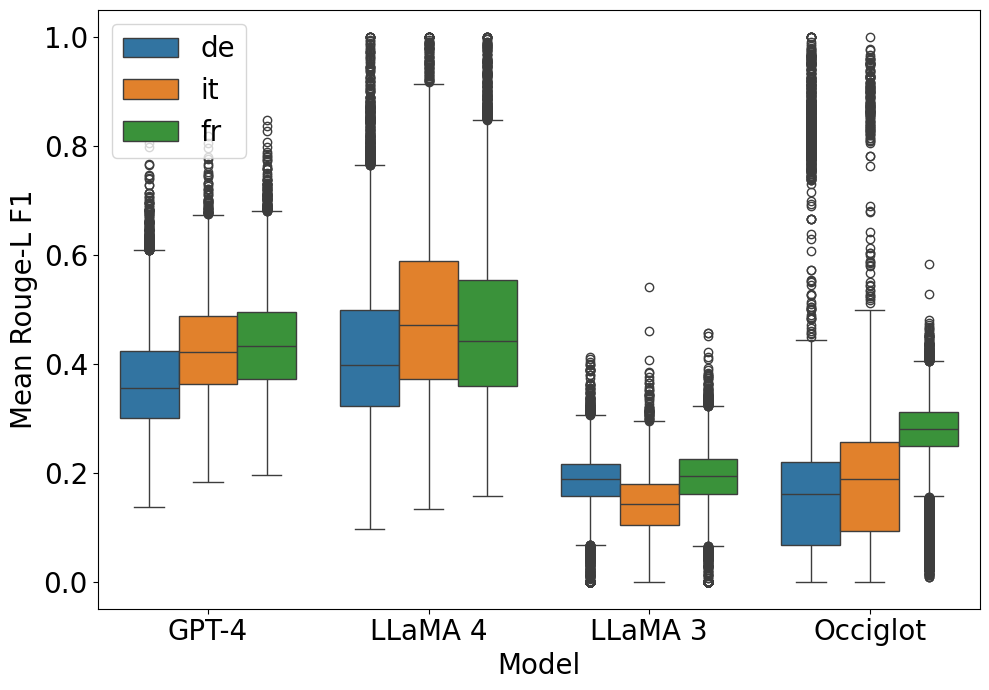

In [4]:
plt.figure(figsize=(10, 7))
sns.boxplot(x="model", y="average_F1", data=rogue.to_pandas(),
            hue="language",
            order=[
                "gpt-4.1-mini", "llama_4_scout",
                "llama_3.1-8b-instruct", "occiglot-7b-eu5-instruct"]
            )
# plt.title("RogueL Scores by Model and Language")
plt.xlabel("Model", fontsize=fontsize)
plt.ylabel("Mean Rouge-L F1", fontsize=fontsize)
plt.legend(loc="upper left", fontsize=fontsize)
plt.xticks(ticks = [0, 1, 2, 3],
           labels=["GPT-4", "LLaMA 4", "LLaMA 3", "Occiglot"],
           fontsize=fontsize
           )
plt.yticks(fontsize=fontsize)
plt.tight_layout()
plt.savefig("figures/rogue-l.pdf", bbox_inches="tight", format="pdf")
plt.show()

In [12]:
bert_score_de = pl.read_csv("bert_score_de.csv").with_columns(
    pl.lit("de").alias("language")
)
bert_score_it = pl.read_csv("bert_score_it.csv").with_columns(
    pl.lit("it").alias("language")
)
bert_score_fr = pl.read_csv("bert_score_fr.csv").with_columns(
    pl.lit("fr").alias("language")
)

bert_score = pl.concat([bert_score_de, bert_score_it, bert_score_fr], how="vertical")

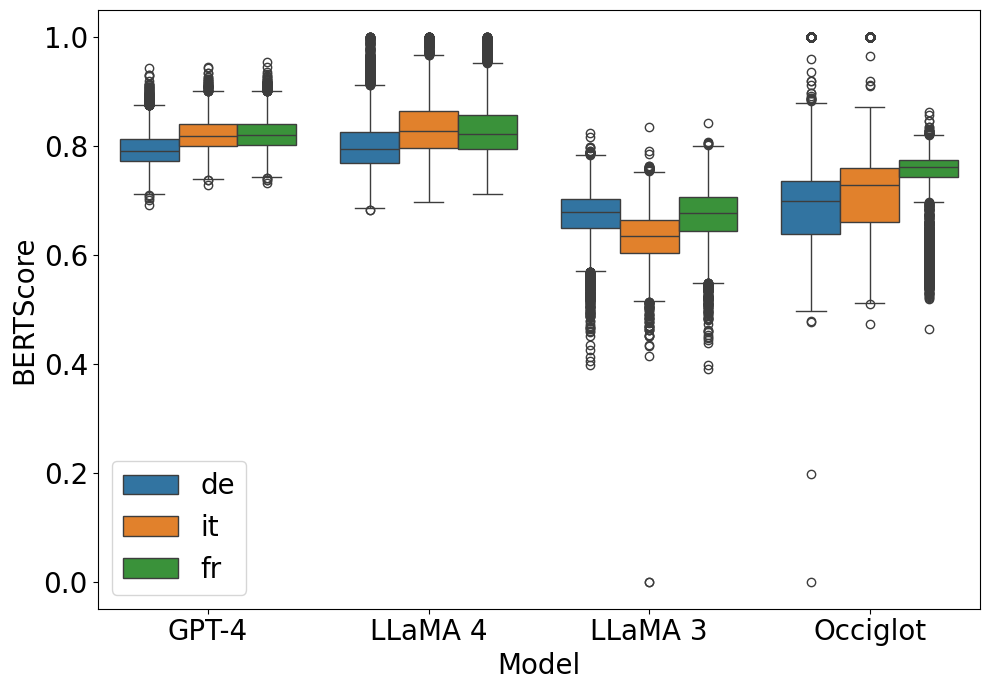

In [37]:
plt.figure(figsize=(10, 7))
sns.boxplot(x="model", y="f1", data=bert_score.to_pandas(),
            hue="language",
            order=[
                "gpt-4.1-mini", "llama_4_scout",
                "llama_3.1-8b-instruct", "occiglot-7b-eu5-instruct"]
            )
# plt.title("BERTScore by Model and Language")
plt.xlabel("Model", fontsize=fontsize)
plt.ylabel("BERTScore", fontsize=fontsize)
plt.legend(loc="lower left", fontsize=fontsize)
plt.xticks(ticks = [0, 1, 2, 3],
           labels=["GPT-4", "LLaMA 4", "LLaMA 3", "Occiglot"],
           fontsize=fontsize
           )
plt.yticks(fontsize=fontsize)
plt.tight_layout()
plt.savefig("figures/bert-score.pdf", bbox_inches="tight", format="pdf")
plt.show()

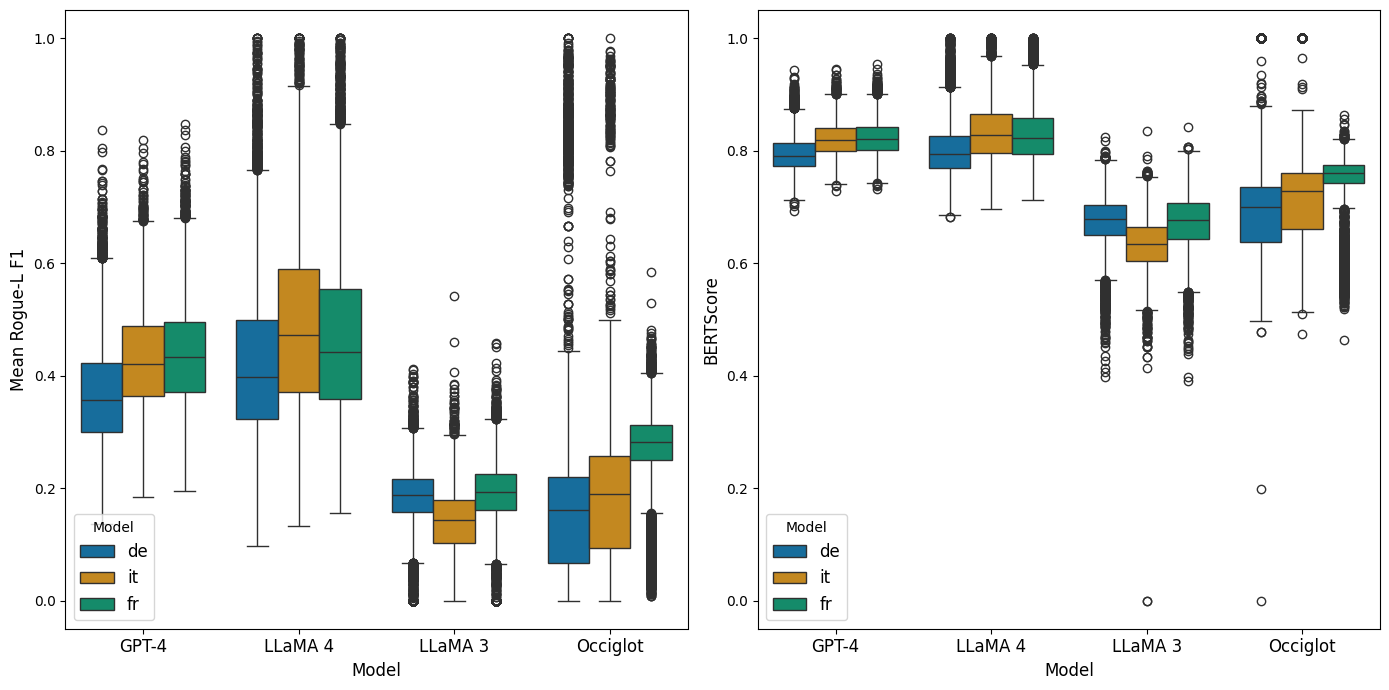

In [22]:
sns.color_palette("colorblind")
fontsize = 12
# both scores in one plot
figs,axs = plt.subplots(1, 2, figsize=(14, 7))
sns.boxplot(x="model", y="average_F1", data=rogue.to_pandas(),
            hue="language",
            order=[
                "gpt-4.1-mini", "llama_4_scout",
                "llama_3.1-8b-instruct", "occiglot-7b-eu5-instruct"],
            palette="colorblind",
            ax=axs[0])
# axs[0].set_title("RogueL Scores by Model and Language")
axs[0].set_xlabel("Model", fontsize=fontsize)
axs[0].set_ylabel("Mean Rogue-L F1", fontsize=fontsize)
axs[0].legend(title="Model", loc="lower left", fontsize=fontsize)
axs[0].set_xticks(ticks = [0, 1, 2, 3],
           labels=["GPT-4", "LLaMA 4", "LLaMA 3", "Occiglot"],
           fontsize=fontsize
           )
sns.boxplot(x="model", y="f1", data=bert_score.to_pandas(),
            hue="language",
            order=[
                "gpt-4.1-mini", "llama_4_scout",
                "llama_3.1-8b-instruct", "occiglot-7b-eu5-instruct"],
            palette="colorblind",
            ax=axs[1])
# axs[1].set_title("BERTScore by Model and Language")
axs[1].set_xlabel("Model", fontsize=fontsize)
axs[1].set_ylabel("BERTScore", fontsize=fontsize)
axs[1].legend(title="Model", loc="lower left", fontsize=fontsize)
axs[1].set_xticks(ticks = [0, 1, 2, 3],
           labels=["GPT-4", "LLaMA 4", "LLaMA 3", "Occiglot"],
           fontsize=fontsize
           )
plt.tight_layout()
plt.savefig("figures/rogue-bert.pdf", bbox_inches="tight", format="pdf")
plt.show()